Import libraries

In [1]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [2]:
%time train_df = pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/val_men.csv")

CPU times: user 17.9 ms, sys: 11.1 ms, total: 29 ms
Wall time: 28.5 ms
CPU times: user 11.7 ms, sys: 3.97 ms, total: 15.6 ms
Wall time: 15.6 ms
CPU times: user 5.83 ms, sys: 0 ns, total: 5.83 ms
Wall time: 5.84 ms


In [3]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [4]:
X_train = train_df[in_features].values.astype(float) # type: ignore
y_train = train_df[label_feature].values.astype(float) # type: ignore
t_train = train_df[treatment_feature].values.astype(float) # type: ignore

X_test = test_df[in_features].values.astype(float) # type: ignore
y_test = test_df[label_feature].values.astype(float) # type: ignore
t_test = test_df[treatment_feature].values.astype(float) # type: ignore

X_val = val_df[in_features].values.astype(float) # type: ignore
y_val = val_df[label_feature].values.astype(float) # type: ignore
t_val = val_df[treatment_feature].values.astype(float) # type: ignore

In [5]:
print('X_train[:10]', X_train[:1].astype(float))

X_train[:10] [[-0.21435131  1.6331766   1.0667411   0.90252386 -1.1010233   1.07039981
   1.00043033  2.70003843 -0.88552759 -0.88616046]]


In [6]:
print('y_train[:10]', y_train[:1].astype(float))

y_train[:10] [[0.]]


In [7]:
# Transform to tensor
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

x_men_train_t = to_tensor(X_train)
x_men_val_t = to_tensor(X_val)
x_men_test_t = to_tensor(X_test)

y_men_train_t = to_tensor(y_train).reshape(-1, 1)
y_men_val_t = to_tensor(y_val).reshape(-1, 1)
y_men_test_t = to_tensor(y_test).reshape(-1, 1)

# t_train/t_val/t_test cũng tương tự
t_men_train_t = to_tensor(t_train.astype(float)).reshape(-1, 1)
t_men_val_t = to_tensor(t_val.astype(float)).reshape(-1, 1)
t_men_test_t = to_tensor(t_test.astype(float)).reshape(-1, 1)

# Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 6400
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)

print("-------------------------------------------------------------")
print("✅ Completed transform to tensor ✅")
print(f"Shape of train: x={x_men_train_t.shape}; y={y_men_train_t.shape}; t={t_men_train_t.shape}")
print(f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print(f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅ Completed transform to tensor ✅
Shape of train: x=torch.Size([25567, 10]); y=torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


In [8]:
epochs = 50
lr = 1e-4
wd = 1e-5
early_stop_metric = "qini"
ema = True
ema_alpha = 0.15
patience = 15
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start = 0
print (f" epochs = {epochs}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")
print (f" early stop start = {early_stop_start}")

 epochs = 50
 learning rate = 0.0001
 weight decay = 1e-05
 early stop = qini
 use ema = True
 ema alpha = 0.15
 patience = 15
 shared hidden = 200
 outcome hidden = 100
 early stop start = 0


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 445.2258 | Val Loss: 498.8729 | Val Qini: 0.7154 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.7154 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 646.7974 | Val Loss: 498.7867 | Val Qini: 0.7854 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.7259 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Loss: 302.9497 | Val Loss: 498.6920 | Val Qini: 0.7889 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.7354 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/50 | Loss: 432.8685 | Val Loss: 498.5851 | Val Qini: 0.7967 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.7446 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/50 | Loss: 365.0077 | Val Loss: 498.4617 | Val Qini: 0.8024 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.7532 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/50 | Loss: 3

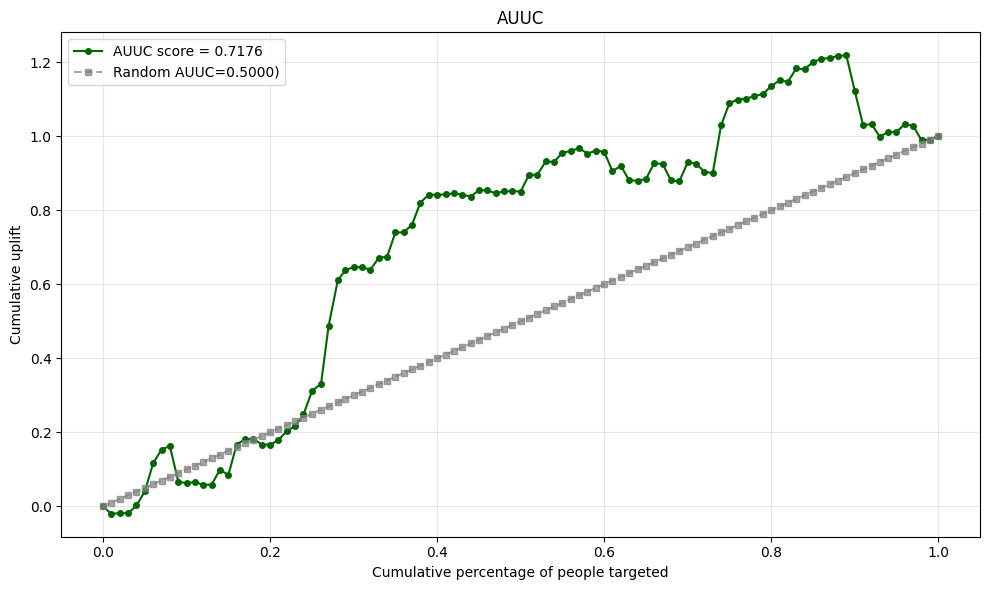

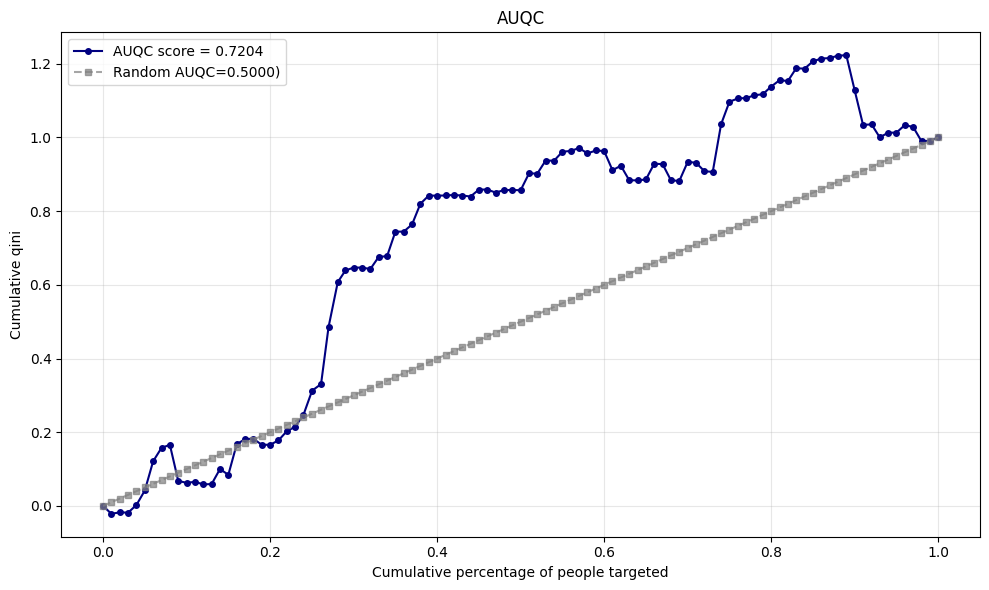

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.718
AUQC: 0.720
Lift: 1.264
KRCC: 0.102
ATE (predicted): -0.0564
ATE (true): 0.5874
ATE error: 0.6438


In [9]:
seed = 412312
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 340.1322 | Val Loss: 498.6832 | Val Qini: 0.7434 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.7434 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 606.3850 | Val Loss: 498.6215 | Val Qini: 0.6995 (patience: 1/15)EMA Trend: 0.7368 | (patience: 1/15)
Epoch 3/50 | Loss: 420.8447 | Val Loss: 498.5544 | Val Qini: 0.6375 (patience: 2/15)EMA Trend: 0.7219 | (patience: 2/15)
Epoch 4/50 | Loss: 478.3469 | Val Loss: 498.4778 | Val Qini: 0.6072 (patience: 3/15)EMA Trend: 0.7047 | (patience: 3/15)
Epoch 5/50 | Loss: 478.7154 | Val Loss: 498.3868 | Val Qini: 0.5883 (patience: 4/15)EMA Trend: 0.6873 | (patience: 4/15)
Epoch 6/50 | Loss: 174.3528 | Val Loss: 498.2772 | Val Qini: 0.5975 (patience: 5/15)EMA Trend: 0

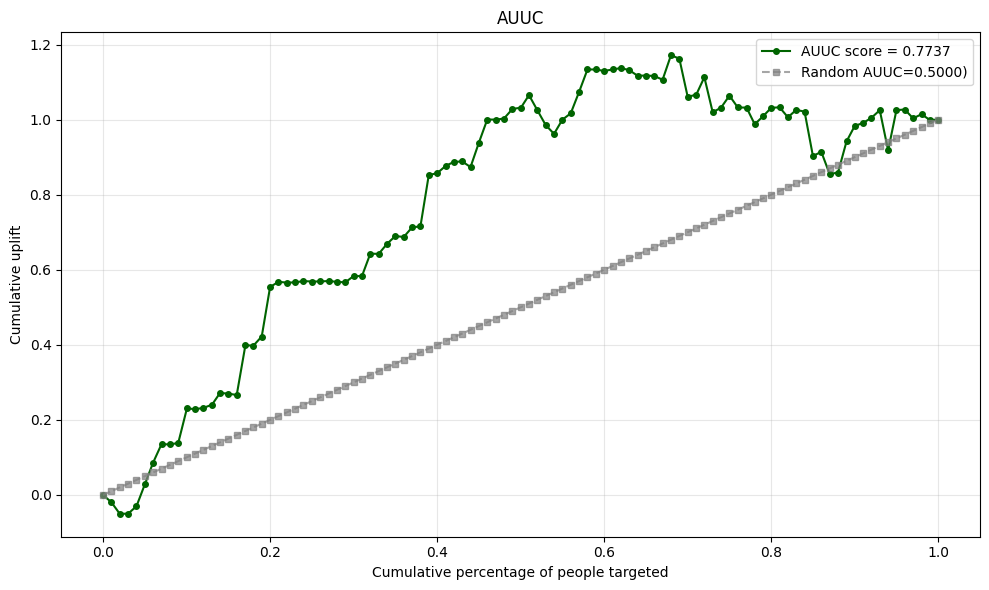

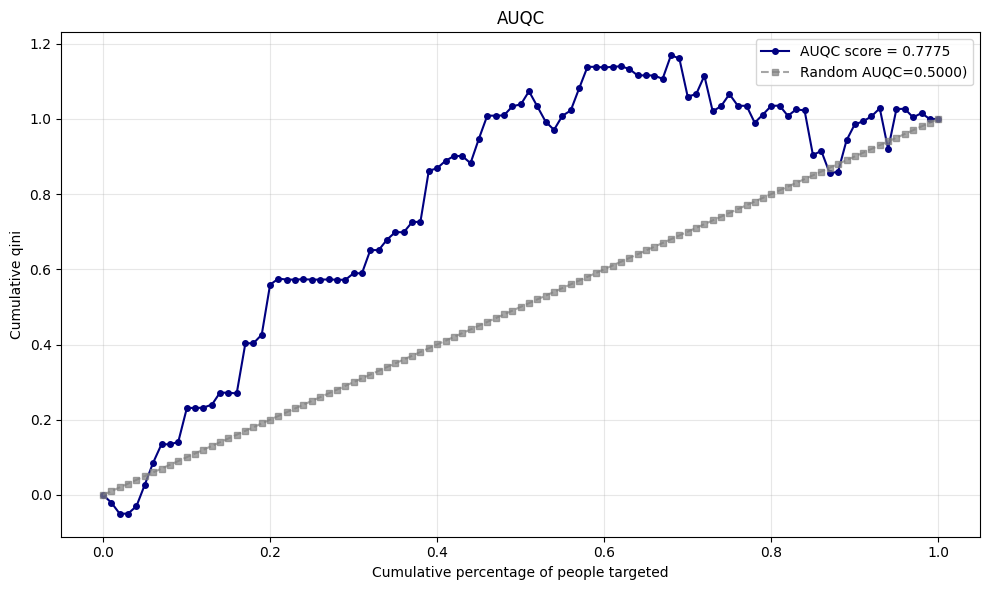

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.774
AUQC: 0.777
Lift: 1.141
KRCC: 0.115
ATE (predicted): -0.0308
ATE (true): 0.5874
ATE error: 0.6182


In [10]:
seed = 42
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 289.6002 | Val Loss: 498.6999 | Val Qini: 0.6598 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6598 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 433.5770 | Val Loss: 498.6449 | Val Qini: 0.6786 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6626 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Loss: 462.1503 | Val Loss: 498.5886 | Val Qini: 0.6596 (patience: 1/15)EMA Trend: 0.6622 | (patience: 1/15)
Epoch 4/50 | Loss: 340.9373 | Val Loss: 498.5291 | Val Qini: 0.6637 ✓ above trend but not peak (patience: 2/15)EMA Trend: 0.6624 | ✓ above trend but not peak (patience: 2/15)
Epoch 5/50 | Loss: 533.7996 | Val Loss: 498.4645 | Val Qini: 0.6537 (patience: 3/15)EMA Trend: 0.6611 | (patience: 3/15)
Epoch 6/50 | Loss: 578

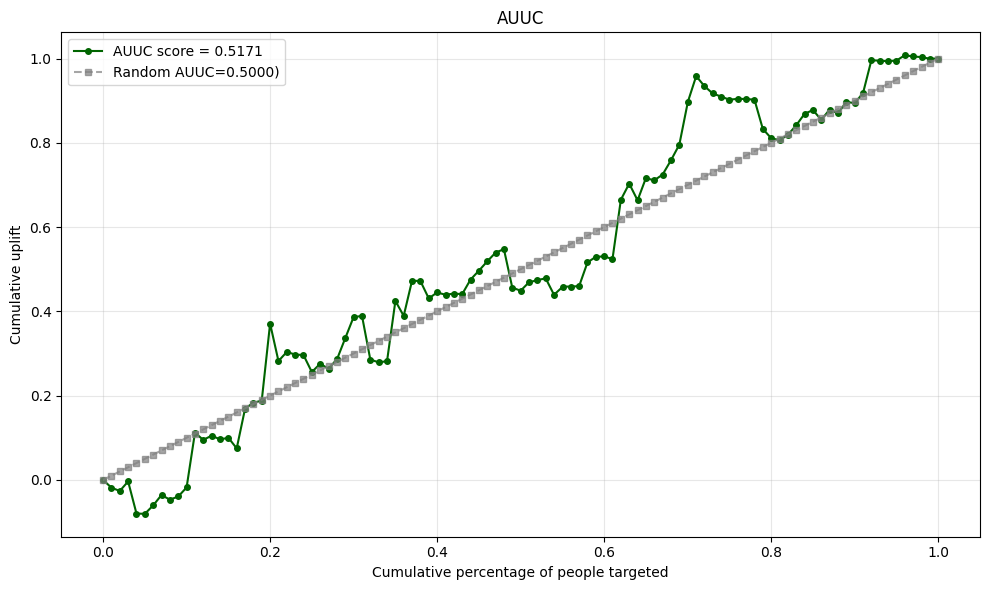

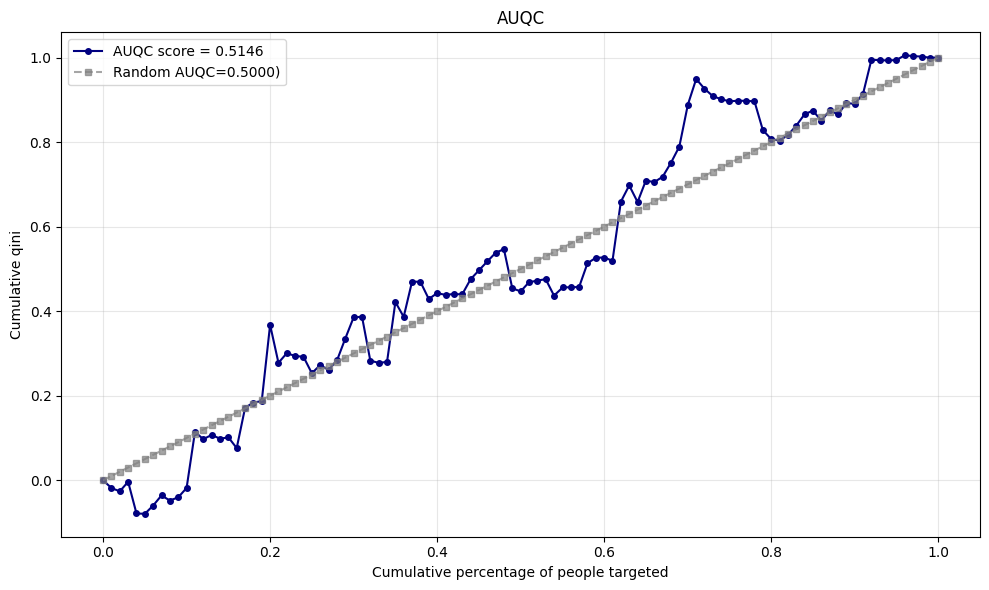

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.517
AUQC: 0.515
Lift: 0.757
KRCC: -0.038
ATE (predicted): 0.8592
ATE (true): 0.5874
ATE error: 0.2717


In [11]:
seed =1874
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 532.8641 | Val Loss: 498.8152 | Val Qini: 0.2406 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2406 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 239.3672 | Val Loss: 498.7482 | Val Qini: 0.3989 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2644 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Loss: 554.8507 | Val Loss: 498.6824 | Val Qini: 0.4483 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2920 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/50 | Loss: 535.5907 | Val Loss: 498.6184 | Val Qini: 0.4571 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3167 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/50 | Loss: 352.5246 | Val Loss: 498.5529 | Val Qini: 0.4582 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3380 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/50 | Loss: 2

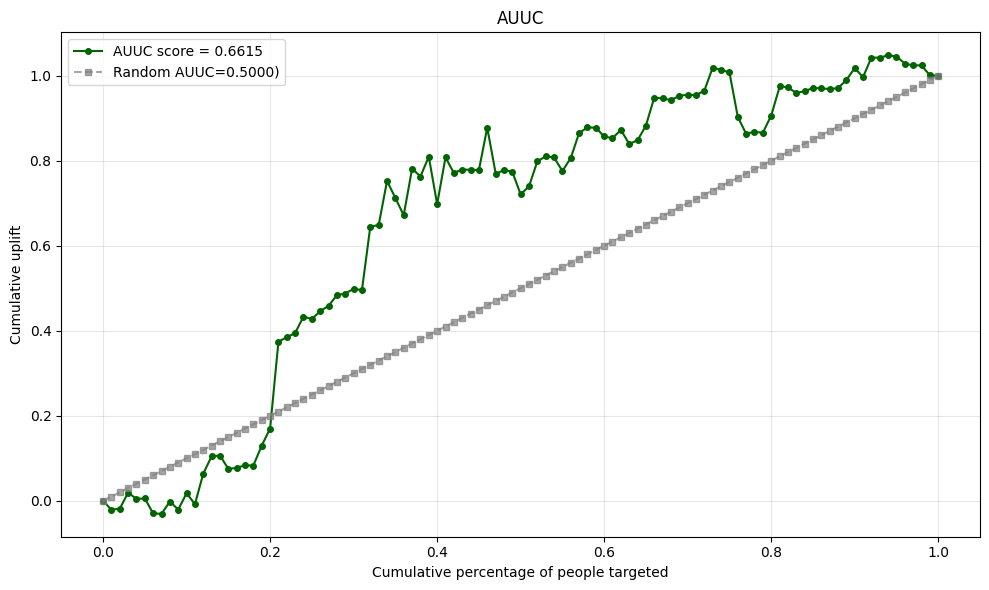

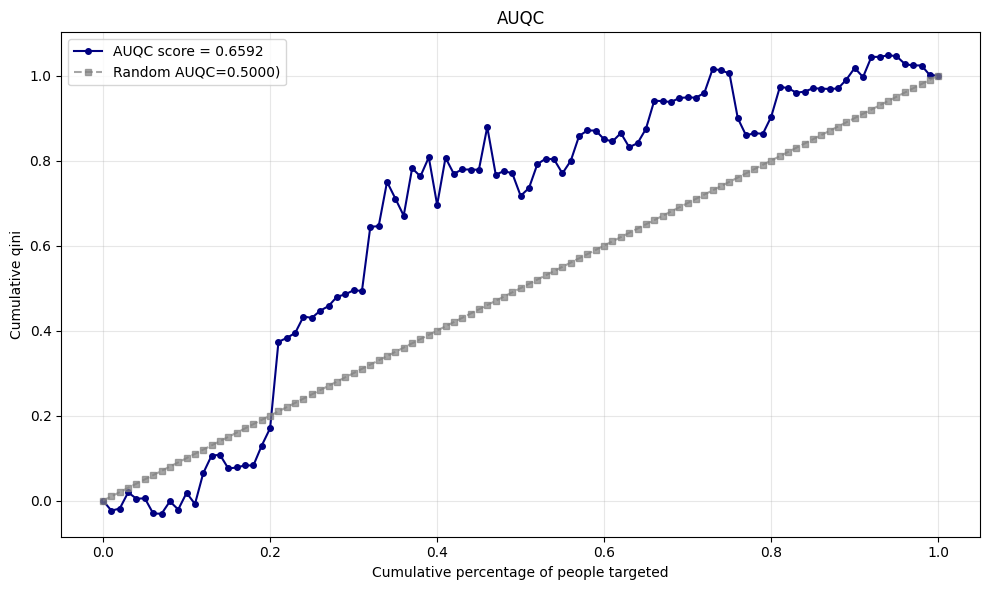

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.662
AUQC: 0.659
Lift: 0.976
KRCC: 0.072
ATE (predicted): 0.8275
ATE (true): 0.5874
ATE error: 0.2401


In [12]:
seed = 902745
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/50 | Loss: 301.2266 | Val Loss: 498.7985 | Val Qini: 0.6275 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6275 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/50 | Loss: 405.3932 | Val Loss: 498.7450 | Val Qini: 0.6903 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6370 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/50 | Loss: 419.0568 | Val Loss: 498.6901 | Val Qini: 0.6757 ✓ above trend but not peak (patience: 1/15)EMA Trend: 0.6428 | ✓ above trend but not peak (patience: 1/15)
Epoch 4/50 | Loss: 553.0239 | Val Loss: 498.6301 | Val Qini: 0.6910 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6500 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/50 | Loss: 469.2814 | Val Loss: 498.5648 | Val Qini: 0.6933 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6565 | ⭐ NEW BEST (pea

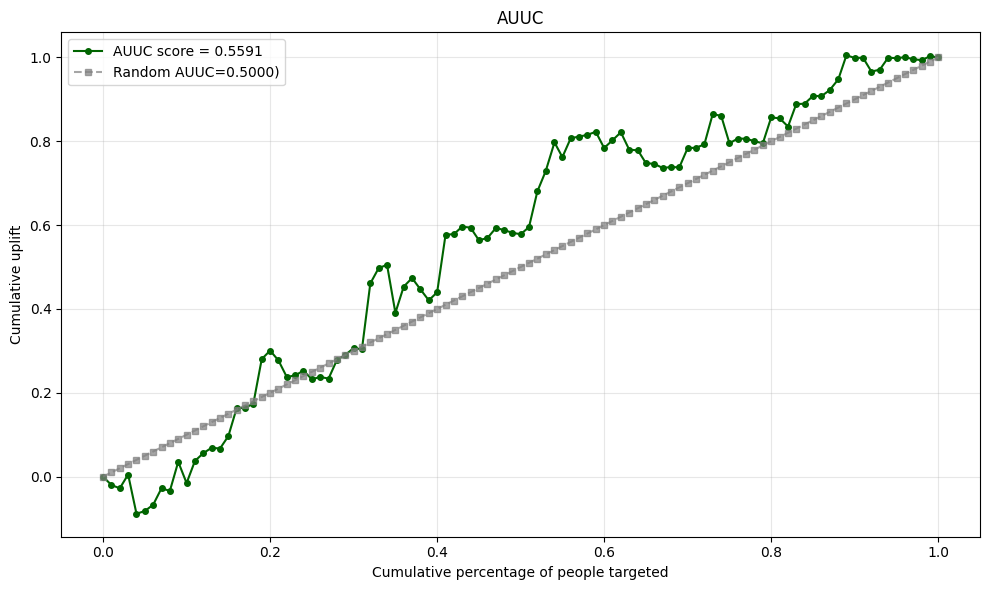

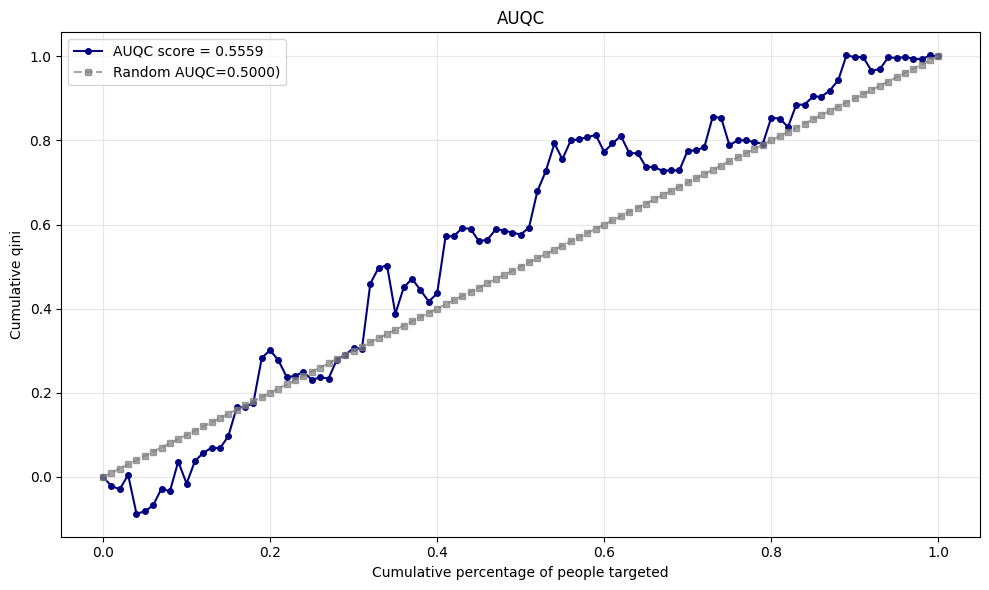

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.559
AUQC: 0.556
Lift: 0.599
KRCC: 0.052
ATE (predicted): 0.8558
ATE (true): 0.5874
ATE error: 0.2684


In [13]:
seed = 1
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")